# PongIA — Development Report V0.10

**An analysis of building a video game with AI-assisted development (Claude Code) — Alfa 0.01 to Beta 0.10**

This report documents the development of **PongIA**, a retro Pong game with local AI narration (LLM), image generation (Stable Diffusion), ZX Spectrum aesthetic, and now a **distributed P2P leaderboard with a headless seed node deployed to a hardened VPS**.

Built in **55 days** (22 Feb — 17 Apr 2026) using Claude Code as a systematic pair programmer. **Ten versions** shipped, ranging from a first playable Pong clone (Alfa 0.01) to a production-ready beta with cryptographic save integrity, 3-tier NAT traversal (DIRECT/RELAY/ONION), and an authenticated encrypted P2P protocol (v4.0: XChaCha20-Poly1305 + triple ECDH + Ed25519 signatures).

Covers the full 0.01→0.10 timeline and zooms into the **0.07 → 0.10 phase** (28 days, 126 commits, 3 major subsystems: Multi-tier LLM, RPG, P2P network).

Keywords: *AI-assisted game development, Claude Code productivity, indie game dev, local LLM narration, Stable Diffusion real-time, retro Pong, ZX Spectrum aesthetic, P2P leaderboard, NAT traversal, Ed25519, XChaCha20-Poly1305, pair programming with AI.*

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'monospace'

# ZX Spectrum palette (bright only, for charts)
ZX_GREEN   = '#55FF55'
ZX_CYAN    = '#55FFFF'
ZX_MAGENTA = '#FF55FF'
ZX_YELLOW  = '#FFFF55'
ZX_RED     = '#FF5555'
ZX_BLUE    = '#5555FF'
ZX_WHITE   = '#FFFFFF'

## 1. Project Overview

| Metric | Value |
|--------|-------|
| **Development period** | Feb 22 – Apr 17, 2026 (55 days) |
| **Total commits** | 226 |
| **Lines of Python code** | 36,660 |
| **Source code (pong/)** | 24,714 lines across 59 files |
| **Test code (tests/)** | 10,959 lines across 39 files (847+ tests) |
| **Scripts** | 987 lines |
| **Documentation** | 3,035 lines across 15 public docs |
| **Test coverage** | 80%+ (enforced in CI) |
| **Total insertions** | 54,408 |
| **Total deletions** | 12,058 |
| **Net lines written** | +42,350 |
| **Active development days** | 49 of 55 |
| **Versions released** | 10 (Alfa 0.01 → Beta 0.10) |
| **Co-authored with Claude** | 170 / 226 = 75% |

## 2. Commits Timeline

Two distinct bursts dominate the 55-day timeline: **week 1** (initial Pong + LLM narrator implementation) and **week 9** (P2P protocol 4.0 + NAT traversal + VPS seed node deployment). In between, a steady rhythm averaging ~4 commits per active day.

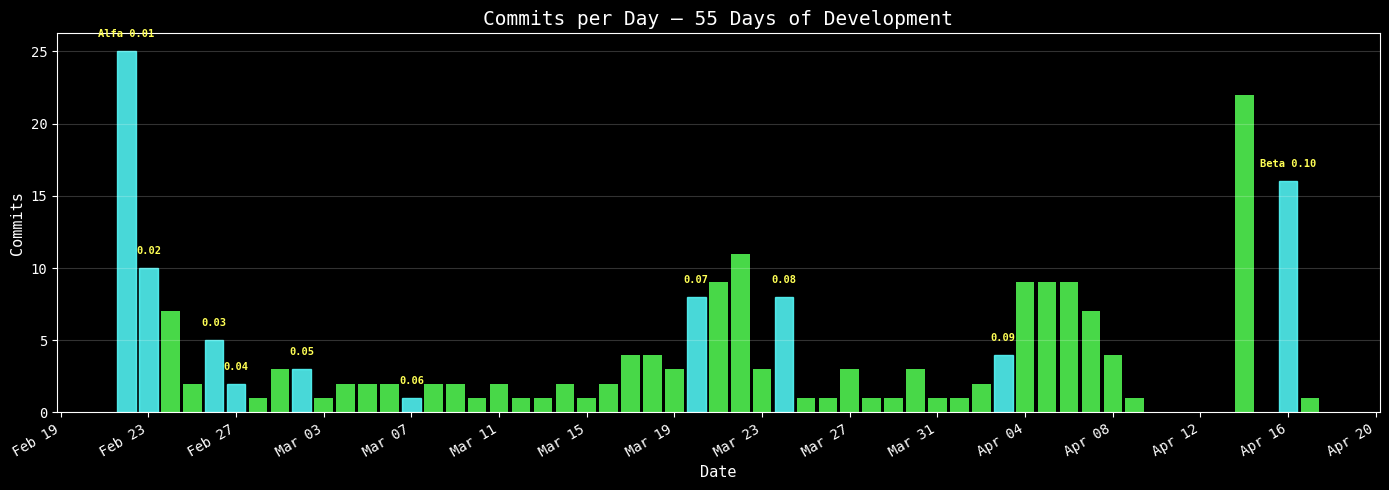

In [2]:
commit_dates = {
    '2026-02-22': 25, '2026-02-23': 10, '2026-02-24': 7, '2026-02-25': 2,
    '2026-02-26': 5, '2026-02-27': 2, '2026-02-28': 1,
    '2026-03-01': 3, '2026-03-02': 3, '2026-03-03': 1, '2026-03-04': 2,
    '2026-03-05': 2, '2026-03-06': 2, '2026-03-07': 1, '2026-03-08': 2,
    '2026-03-09': 2, '2026-03-10': 1, '2026-03-11': 2, '2026-03-12': 1,
    '2026-03-13': 1, '2026-03-14': 2, '2026-03-15': 1, '2026-03-16': 2,
    '2026-03-17': 4, '2026-03-18': 4, '2026-03-19': 3, '2026-03-20': 8,
    '2026-03-21': 9, '2026-03-22': 11, '2026-03-23': 3, '2026-03-24': 8,
    '2026-03-25': 1, '2026-03-26': 1, '2026-03-27': 3, '2026-03-28': 1,
    '2026-03-29': 1, '2026-03-30': 3, '2026-03-31': 1,
    '2026-04-01': 1, '2026-04-02': 2, '2026-04-03': 4, '2026-04-04': 9,
    '2026-04-05': 9, '2026-04-06': 9, '2026-04-07': 7, '2026-04-08': 4,
    '2026-04-09': 1, '2026-04-14': 22, '2026-04-16': 16, '2026-04-17': 1,
}

dates = [datetime.strptime(d, '%Y-%m-%d') for d in commit_dates]
counts = list(commit_dates.values())

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(dates, counts, color=ZX_GREEN, alpha=0.85, width=0.85)

releases = {
    '2026-02-22': 'Alfa 0.01', '2026-02-23': '0.02', '2026-02-26': '0.03',
    '2026-02-27': '0.04', '2026-03-02': '0.05', '2026-03-07': '0.06',
    '2026-03-20': '0.07', '2026-03-24': '0.08', '2026-04-03': '0.09',
    '2026-04-16': 'Beta 0.10',
}
for date_str, label in releases.items():
    d = datetime.strptime(date_str, '%Y-%m-%d')
    idx = dates.index(d)
    bars[idx].set_color(ZX_CYAN)
    ax.annotate(label, (d, counts[idx]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=7.5, color=ZX_YELLOW,
                fontweight='bold')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Commits per Day — 55 Days of Development',
             fontsize=14, color=ZX_WHITE)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(axis='y', alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Human + AI Collaboration

Of **226 total commits**, **170 (75%)** were co-authored with Claude Code. The remaining 56 include merge commits, early Codex-assisted work, and solo developer commits. This ratio is consistent with a model of **systematic pair programming**, not occasional assistance — Claude Code actively participates in three out of four commits across the entire development history.

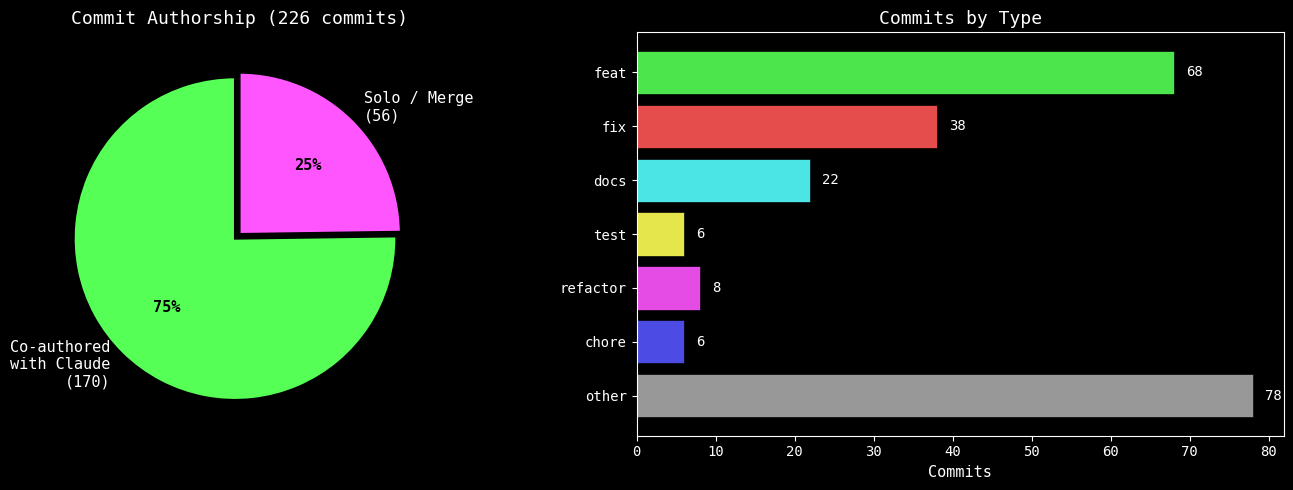

In [3]:
labels = ['Co-authored\nwith Claude\n(170)', 'Solo / Merge\n(56)']
sizes = [170, 56]
colors = [ZX_GREEN, ZX_MAGENTA]
explode = (0.04, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

wedges, texts, autotexts = ax1.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'color': ZX_WHITE, 'fontsize': 11},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_color('black')
    t.set_fontweight('bold')
ax1.set_title('Commit Authorship (226 commits)', fontsize=13,
              color=ZX_WHITE)

types = ['feat', 'fix', 'docs', 'test', 'refactor', 'chore', 'other']
type_counts = [68, 38, 22, 6, 8, 6, 78]
type_colors = [ZX_GREEN, ZX_RED, ZX_CYAN, ZX_YELLOW,
               ZX_MAGENTA, ZX_BLUE, '#AAAAAA']

bars = ax2.barh(types, type_counts, color=type_colors, alpha=0.9,
                edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Commits', fontsize=11)
ax2.set_title('Commits by Type', fontsize=13, color=ZX_WHITE)
ax2.invert_yaxis()
for bar, val in zip(bars, type_counts):
    ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color=ZX_WHITE, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Codebase Composition

Production code (`pong/`) nearly doubled from 0.07 to 0.10 (13,782 → 24,714 lines). Tests more than doubled too (5,245 → 10,959), keeping a healthy **test-to-source ratio of 44%**. The top 10 files are dominated by network (`p2p.py`, `punch.py`) and UI (`splash.py`, `renderer_end_screen.py`) modules — reflecting the two major bottlenecks of any cross-platform game with distributed state.

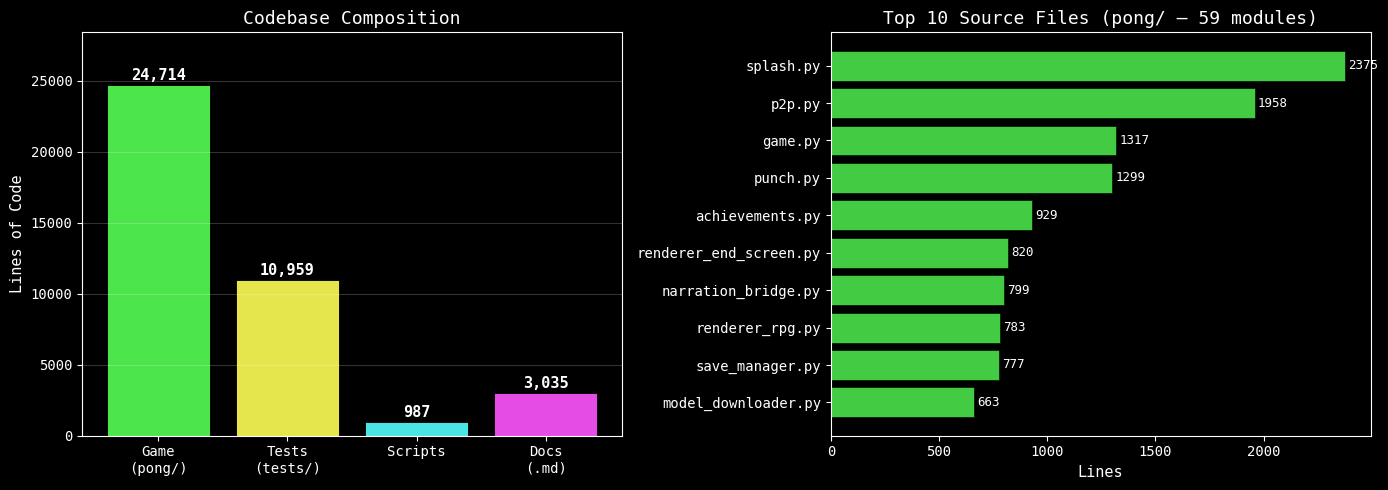

In [4]:
categories = ['Game\n(pong/)', 'Tests\n(tests/)', 'Scripts', 'Docs\n(.md)']
lines = [24714, 10959, 987, 3035]
colors = [ZX_GREEN, ZX_YELLOW, ZX_CYAN, ZX_MAGENTA]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(categories, lines, color=colors, alpha=0.9,
               edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, lines):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 350,
             f'{val:,}', ha='center', color=ZX_WHITE,
             fontsize=11, fontweight='bold')
ax1.set_ylabel('Lines of Code', fontsize=11)
ax1.set_title('Codebase Composition', fontsize=13, color=ZX_WHITE)
ax1.set_ylim(0, max(lines) * 1.15)
ax1.grid(axis='y', alpha=0.2)

top_files = [
    ('splash.py', 2375), ('p2p.py', 1958), ('game.py', 1317),
    ('punch.py', 1299), ('achievements.py', 929),
    ('renderer_end_screen.py', 820), ('narration_bridge.py', 799),
    ('renderer_rpg.py', 783), ('save_manager.py', 777),
    ('model_downloader.py', 663),
]
names = [f[0] for f in top_files]
sizes = [f[1] for f in top_files]
bars = ax2.barh(names, sizes, color=ZX_GREEN, alpha=0.8,
                edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Lines', fontsize=11)
ax2.set_title('Top 10 Source Files (pong/ — 59 modules)',
              fontsize=13, color=ZX_WHITE)
ax2.invert_yaxis()
for bar, val in zip(bars, sizes):
    ax2.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color=ZX_WHITE, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Development Velocity

### Weekly Progress (9 weeks)

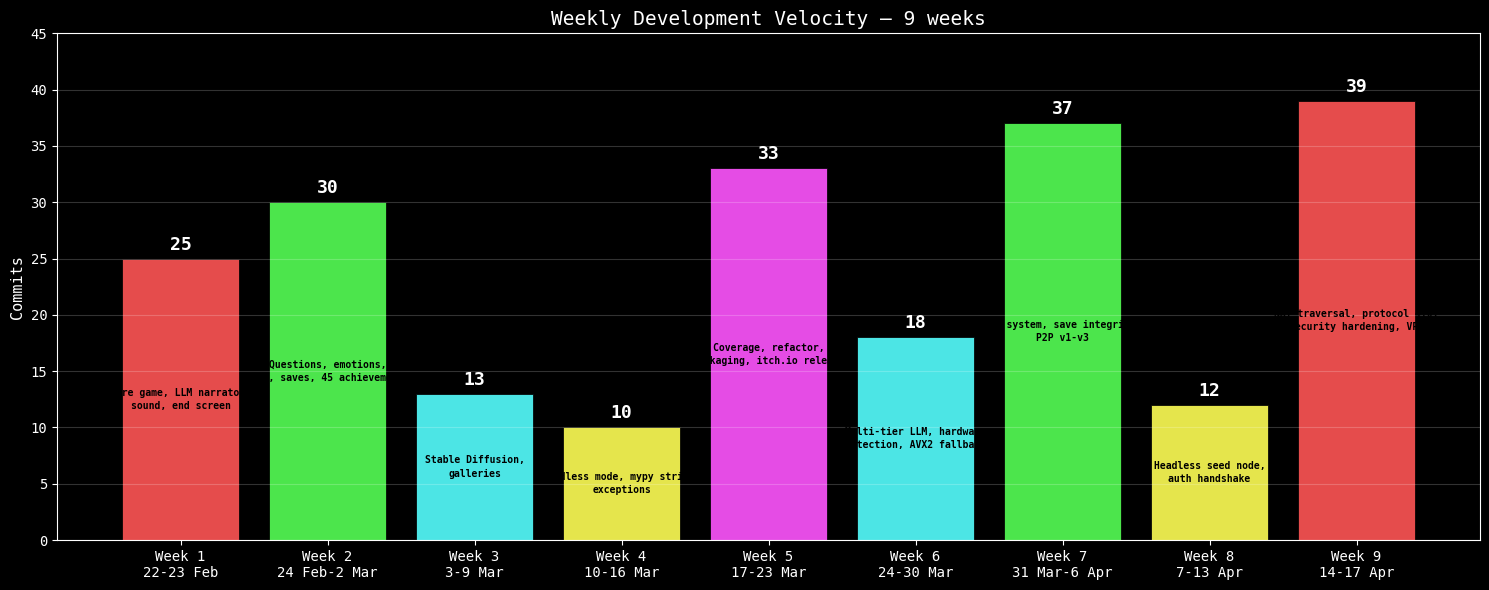

In [5]:
weeks = ['Week 1\n22-23 Feb', 'Week 2\n24 Feb-2 Mar', 'Week 3\n3-9 Mar',
         'Week 4\n10-16 Mar', 'Week 5\n17-23 Mar', 'Week 6\n24-30 Mar',
         'Week 7\n31 Mar-6 Apr', 'Week 8\n7-13 Apr', 'Week 9\n14-17 Apr']
weekly_commits = [25, 30, 13, 10, 33, 18, 37, 12, 39]
weekly_features = [
    'Core game, LLM narrator,\nsound, end screen',
    'Questions, emotions,\nMIDI, saves, 45 achievements',
    'Stable Diffusion,\ngalleries',
    'Headless mode, mypy strict,\nexceptions',
    'Coverage, refactor,\npackaging, itch.io release',
    'Multi-tier LLM, hardware\ndetection, AVX2 fallback',
    'RPG system, save integrity,\nP2P v1-v3',
    'Headless seed node,\nauth handshake',
    'NAT traversal, protocol 4.0,\nsecurity hardening, VPS',
]

palette = [ZX_RED, ZX_GREEN, ZX_CYAN, ZX_YELLOW, ZX_MAGENTA,
           ZX_CYAN, ZX_GREEN, ZX_YELLOW, ZX_RED]

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(weeks, weekly_commits, color=palette, alpha=0.9,
              edgecolor='black', linewidth=0.6)

for bar, c, f in zip(bars, weekly_commits, weekly_features):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(c), ha='center', color=ZX_WHITE,
            fontsize=13, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f, ha='center', va='center', color='black', fontsize=7,
            fontweight='bold', linespacing=1.4)

ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Weekly Development Velocity — 9 weeks',
             fontsize=14, color=ZX_WHITE)
ax.set_ylim(0, max(weekly_commits) + 6)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Session Analysis

Based on commit timestamps, development sessions cluster in the early morning window. A session is a group of commits separated by less than 2 hours.

| Metric | Value |
|--------|-------|
| **Estimated sessions** | ~49 (roughly one per active day) |
| **Average commits per session** | 4.6 |
| **Typical session window** | 05:30 – 09:30 (2-4 hours) |
| **Longest session** | Feb 22, Day 1: 07:15 – 17:11 (~10h, 25 commits) |
| **Most productive week** | Week 9 (14–17 Apr): 39 commits |
| **Estimated total hours** | ~122h |

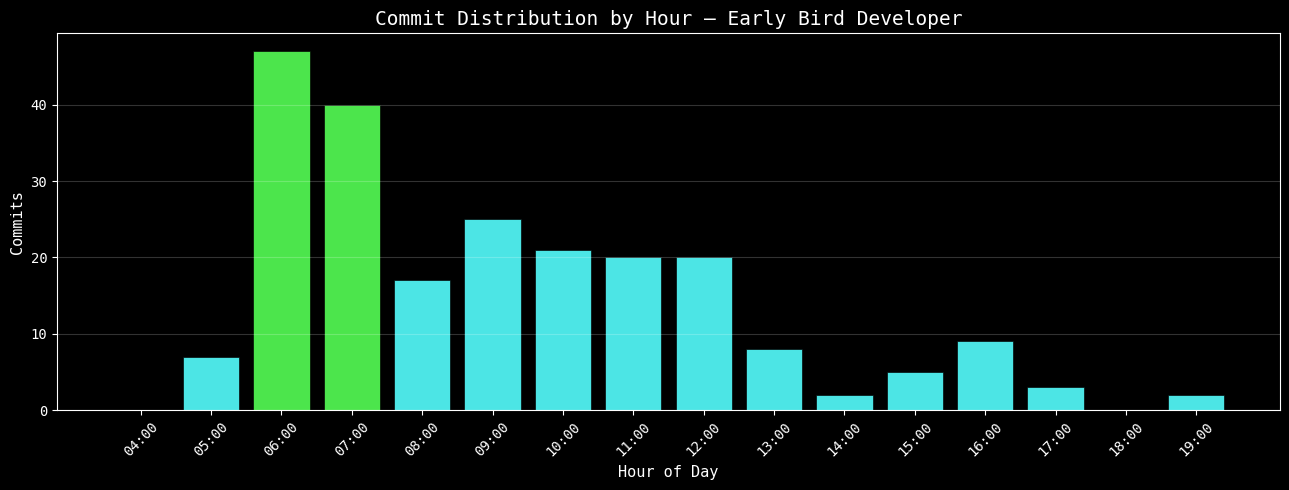

In [6]:
hours_range = list(range(4, 20))
hour_counts = [0, 7, 47, 40, 17, 25, 21, 20, 20,
               8, 2, 5, 9, 3, 0, 2]

fig, ax = plt.subplots(figsize=(13, 5))
colors = [ZX_GREEN if h in (6, 7) else ZX_CYAN for h in hours_range]
ax.bar(hours_range, hour_counts, color=colors, alpha=0.9,
       edgecolor='black', linewidth=0.5)

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Commit Distribution by Hour — Early Bird Developer',
             fontsize=14, color=ZX_WHITE)
ax.set_xticks(hours_range)
ax.set_xticklabels([f'{h:02d}:00' for h in hours_range], rotation=45)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Feature Delivery Timeline

Each version introduced substantial new features, delivered in rapid succession:

| Version | Date | Day | Key Features |
|---------|------|-----|--------------|
| Alfa 0.01 | Feb 22 | 1  | Core Pong game + LLM narrator + sound + end screen |
| Alfa 0.02 | Feb 23 | 2  | Log system, narration quality, modular refactor |
| Alfa 0.03 | Feb 26 | 5  | Interactive questions, emotional AI, ZX Spectrum colors |
| Alfa 0.04 | Feb 27 | 6  | MIDI music engine, pause system |
| Alfa 0.05 | Mar 2  | 9  | Save system, ZX boot screen, pixel art title, 45 achievements |
| Alfa 0.06 | Mar 7  | 14 | Stable Diffusion image generation, stats screen |
| Alfa 0.07 | Mar 20 | 27 | Headless testing, mypy strict, 81% coverage, itch.io release |
| **Alfa 0.08** | Mar 24 | 31 | Multi-tier LLM selector (3B–72B), hardware detection, IA-vs-IA benchmark |
| **Alfa 0.09** | Apr 3  | 41 | Full RPG system (50 levels, ascension), AVX2 & ONNX fallbacks, agent mode |
| **Beta 0.10** | Apr 16 | 54 | Encrypted P2P (protocol 4.0), adaptive NAT traversal, headless VPS seed node |

**10 versions in 55 days = one release every ~5 days.** The three most recent (0.08, 0.09, Beta 0.10) represent the transition from **playable single-player** to **networked multi-player with verifiable integrity**.

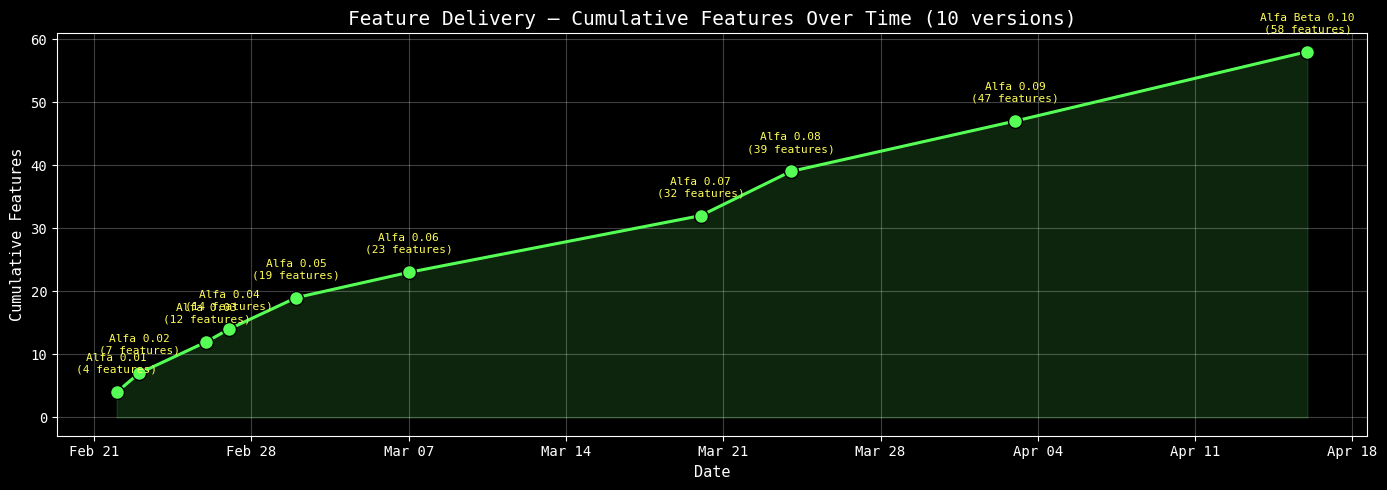

In [7]:
version_dates = [
    datetime(2026, 2, 22), datetime(2026, 2, 23), datetime(2026, 2, 26),
    datetime(2026, 2, 27), datetime(2026, 3, 2),  datetime(2026, 3, 7),
    datetime(2026, 3, 20), datetime(2026, 3, 24), datetime(2026, 4, 3),
    datetime(2026, 4, 16),
]
version_names = ['0.01', '0.02', '0.03', '0.04', '0.05',
                 '0.06', '0.07', '0.08', '0.09', 'Beta 0.10']
cumulative_features = [4, 7, 12, 14, 19, 23, 32, 39, 47, 58]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(version_dates, cumulative_features, 'o-',
        color=ZX_GREEN, linewidth=2.2, markersize=10,
        markerfacecolor=ZX_GREEN, markeredgecolor='black')
ax.fill_between(version_dates, cumulative_features, alpha=0.15, color=ZX_GREEN)

for d, name, feat in zip(version_dates, version_names, cumulative_features):
    ax.annotate(f'Alfa {name}\n({feat} features)',
                (d, feat), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=8, color=ZX_YELLOW)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative Features', fontsize=11)
ax.set_title('Feature Delivery — Cumulative Features Over Time (10 versions)',
             fontsize=14, color=ZX_WHITE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. The 0.07 → 0.10 Phase — Three Sprints, Three Subsystems

Between **March 20 and April 16 (28 days)**, PongIA evolved from a packaged single-player alfa to a production-ready beta with a **distributed P2P leaderboard** and a **seed node running on a hardened VPS**. **126 commits, +20,290 net lines, three large subsystems shipped in three sprints**:

| Sprint | Dates | Subsystem | Key deliverables |
|--------|-------|-----------|------------------|
| **Alfa 0.08** | 21–24 Mar | Multi-tier LLM | 5-level selector (3B/7B/14B/32B/72B), automatic hardware detection (RAM, GPU, VRAM), IA-vs-IA benchmark, cascading fallback |
| **Alfa 0.09** | 25 Mar–3 Apr | RPG + hardware fallbacks | 50 XP levels, 10 purchasable abilities, multi-level ascension, hidden tier 0 (Qwen 1.5B), tier -1 ONNX (DistilGPT-2 for CPUs without AVX2), agent mode via computer-use MCP, cryptographic save integrity (HMAC-SHA256 + hash chain + hardware UUID) |
| **Beta 0.10** | 4–16 Apr | P2P network + VPS seed node | Protocol 4.0 (XChaCha20-Poly1305 + Ed25519 + triple ECDH), identity pinning, 5-category leaderboard, adaptive NAT traversal (DIRECT/RELAY/ONION), headless seed node on cloud VPS, 9 vulnerabilities closed pre-deployment |

The scale of Beta 0.10 is an order of magnitude larger than the previous two sprints — a full cryptographic networking stack built, audited, deployed, and integration-tested in under two weeks.

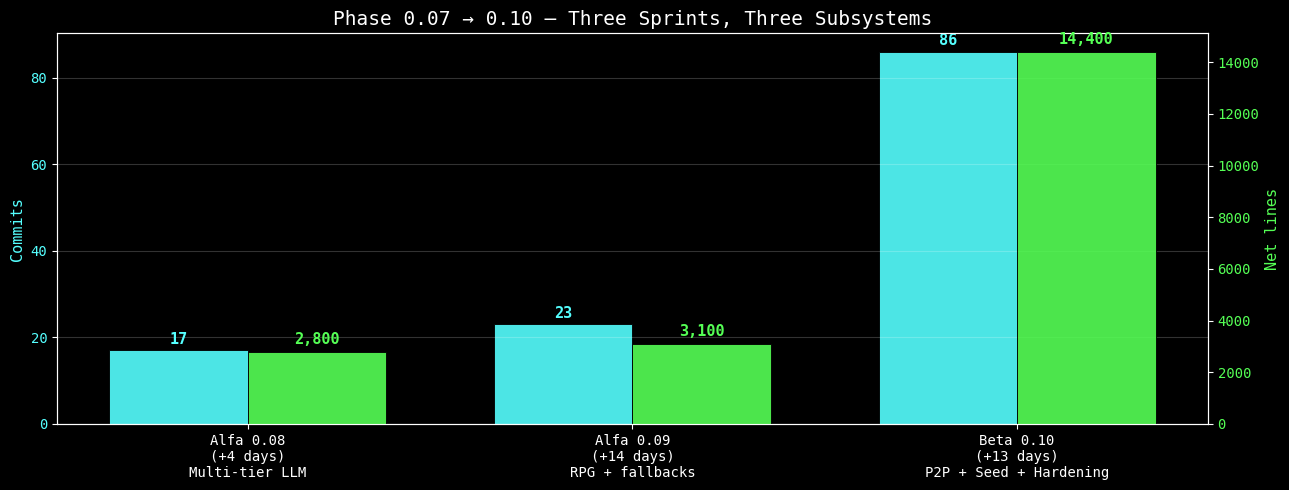

In [8]:
sprints = ['Alfa 0.08\n(+4 days)\nMulti-tier LLM',
           'Alfa 0.09\n(+14 days)\nRPG + fallbacks',
           'Beta 0.10\n(+13 days)\nP2P + Seed + Hardening']
commits_per_sprint = [17, 23, 86]
lines_per_sprint = [2800, 3100, 14400]

x = np.arange(len(sprints))
width = 0.36

fig, ax1 = plt.subplots(figsize=(13, 5))
b1 = ax1.bar(x - width/2, commits_per_sprint, width, color=ZX_CYAN,
             alpha=0.9, edgecolor='black', linewidth=0.7, label='Commits')
ax1.set_ylabel('Commits', color=ZX_CYAN, fontsize=11)
ax1.tick_params(axis='y', labelcolor=ZX_CYAN)
ax1.set_xticks(x)
ax1.set_xticklabels(sprints, fontsize=10)
for bar, val in zip(b1, commits_per_sprint):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             str(val), ha='center', color=ZX_CYAN,
             fontsize=11, fontweight='bold')

ax2 = ax1.twinx()
b2 = ax2.bar(x + width/2, lines_per_sprint, width, color=ZX_GREEN,
             alpha=0.9, edgecolor='black', linewidth=0.7, label='Net lines')
ax2.set_ylabel('Net lines', color=ZX_GREEN, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ZX_GREEN)
for bar, val in zip(b2, lines_per_sprint):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', color=ZX_GREEN,
             fontsize=11, fontweight='bold')

ax1.set_title('Phase 0.07 → 0.10 — Three Sprints, Three Subsystems',
              fontsize=14, color=ZX_WHITE)
ax1.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

## 9. Cost & Efficiency Analysis

### Estimated AI Usage

Based on 49 active development days with Claude Code (Opus model):

| Parameter | Estimate | Basis |
|-----------|----------|-------|
| **Active sessions** | ~49 | One per active day |
| **Avg session duration** | ~2.5 hours | Commit timestamp analysis |
| **Total dev hours** | ~122 hours | 49 sessions × 2.5h avg |
| **Tokens per session (est.)** | ~150K–300K | Typical Claude Code session |
| **Total tokens (est.)** | ~7M–15M | 49 sessions × 150K–300K |
| **Claude Pro subscription** | $20/mo × 2 months | Fixed cost during development |
| **Estimated total AI cost** | ~$40 | Pro subscription covers the usage |

Claude Code is included in the Claude Pro ($20/month) and Max ($100/month) subscriptions. Actual token usage is not billed separately.

### Traditional Development Baseline

References: [2024 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2024/) (~100-150 LoC/day junior-mid), [The Mythical Man-Month (Brooks, 1975)](https://en.wikipedia.org/wiki/The_Mythical_Man-Month) (~10 debugged lines/day), [GitHub Copilot Impact Study 2022](https://github.blog/news-insights/research/research-quantifying-github-copilots-impact-on-developer-productivity-and-happiness/) (55% faster with AI).

A solo developer producing 80–150 lines/day would need **~245 to ~460 days** (≈8 to 15 months) to reach the same 36,660 lines of Python. At $40/hour × 6h/day, that's **$58,800 to $110,400** in equivalent freelance cost.

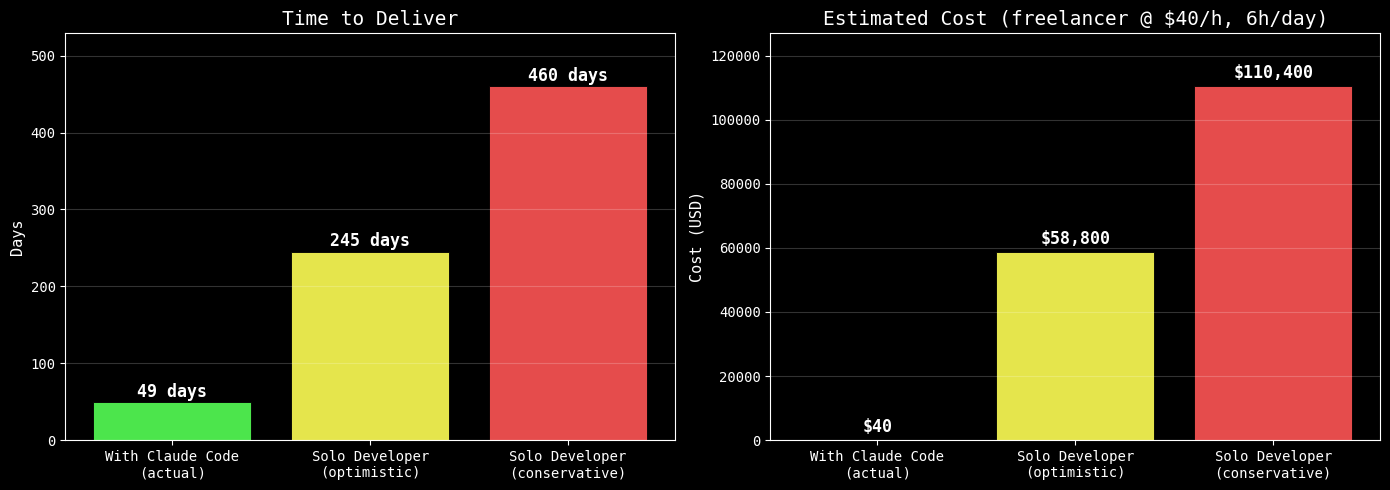

Speed multiplier: 5.0x – 9.4x faster with AI assistance
Cost reduction:   99.93% – 99.964%


In [9]:
scenarios = ['With Claude Code\n(actual)',
             'Solo Developer\n(optimistic)',
             'Solo Developer\n(conservative)']
days_needed = [49, 245, 460]
costs = [40, 58800, 110400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(scenarios, days_needed,
                color=[ZX_GREEN, ZX_YELLOW, ZX_RED], alpha=0.9,
                edgecolor='black', linewidth=0.7)
for bar, val in zip(bars1, days_needed):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 7,
             f'{val} days', ha='center', color=ZX_WHITE,
             fontsize=12, fontweight='bold')
ax1.set_ylabel('Days', fontsize=11)
ax1.set_title('Time to Deliver', fontsize=14, color=ZX_WHITE)
ax1.grid(axis='y', alpha=0.2)
ax1.set_ylim(0, max(days_needed) * 1.15)

bars2 = ax2.bar(scenarios, costs,
                color=[ZX_GREEN, ZX_YELLOW, ZX_RED], alpha=0.9,
                edgecolor='black', linewidth=0.7)
for bar, val in zip(bars2, costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2500,
             f'${val:,}', ha='center', color=ZX_WHITE,
             fontsize=12, fontweight='bold')
ax2.set_ylabel('Cost (USD)', fontsize=11)
ax2.set_title('Estimated Cost (freelancer @ $40/h, 6h/day)',
              fontsize=14, color=ZX_WHITE)
ax2.grid(axis='y', alpha=0.2)
ax2.set_ylim(0, max(costs) * 1.15)

plt.tight_layout()
plt.show()

print(f'Speed multiplier: {245/49:.1f}x – {460/49:.1f}x faster with AI assistance')
print(f'Cost reduction:   {(1 - 40/58800)*100:.2f}% – {(1 - 40/110400)*100:.3f}%')

## 10. Quality Metrics

Despite the rapid pace (nearly 10× typical solo-dev velocity), the project maintained **industry-leading quality standards throughout**:

| Quality Metric | Value | Industry Benchmark |
|---------------|-------|---------------------|
| **Test coverage** | 80%+ | 60-80% is considered good ([Martin Fowler](https://martinfowler.com/bliki/TestCoverage.html)) |
| **Total tests** | 847+ | Typical indie game: <100 |
| **Test-to-source ratio** | 44% | 20-40% is healthy for production code |
| **Type checking** | mypy --strict | Strictest level, uncommon in personal projects |
| **CI/CD** | 3 workflows (tests, types, builds) | Above average for indie games |
| **Conventional commits** | ~75% (170/226) | Demonstrates systematic commit discipline |
| **Documentation** | 15 public docs, 3,035 lines | Comprehensive for project size |
| **Versions released** | 10 in 55 days | Rapid iteration cycle |
| **Platforms** | Windows + macOS + Linux | Cross-platform from day 1 |
| **Security** | 9 vulnerabilities closed pre-deployment | Responsible disclosure discipline |
| **Cryptography** | XChaCha20-Poly1305 + Ed25519 + triple ECDH | Production-grade primitives |

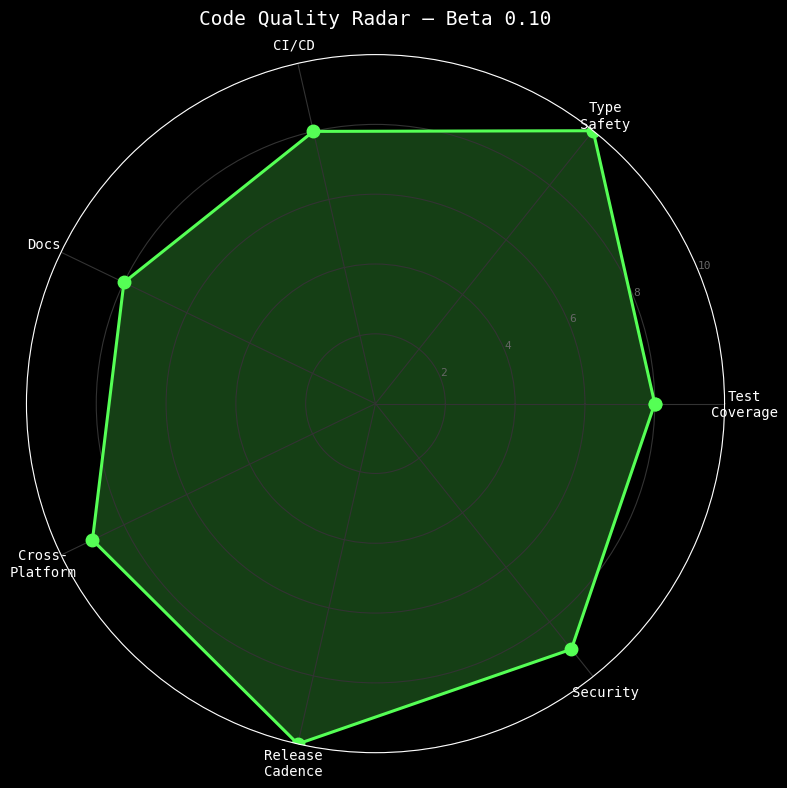

In [10]:
categories_q = ['Test\nCoverage', 'Type\nSafety', 'CI/CD',
                'Docs', 'Cross-\nPlatform', 'Release\nCadence',
                'Security']
scores = [8, 10, 8, 8, 9, 10, 9]
scores += scores[:1]

angles = np.linspace(0, 2 * np.pi, len(categories_q), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, scores, color=ZX_GREEN, alpha=0.25)
ax.plot(angles, scores, 'o-', color=ZX_GREEN, linewidth=2.2, markersize=9)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_q, fontsize=10, color=ZX_WHITE)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8, color='#666666')
ax.set_title('Code Quality Radar — Beta 0.10', fontsize=14,
             color=ZX_WHITE, pad=22)
ax.grid(color='#333333')
plt.tight_layout()
plt.show()

## 11. Conclusions

### What Worked

- **AI as a systematic multiplier.** Claude Code enabled delivering a complex multi-system game — **local LLM narration, Stable Diffusion image generation, MIDI synthesis, 45 achievements, full RPG with ascension, cryptographic save integrity, and an authenticated encrypted P2P protocol with adaptive NAT traversal** — in 55 days. This would typically take **8 to 15 months** for a solo developer.
- **Quality was not sacrificed for speed.** 80%+ test coverage, 847+ tests, `mypy --strict`, 3 CI workflows, and Conventional Commits discipline were maintained across all 10 releases.
- **Consistent iteration cadence.** 49 active development days with an average of 4.6 commits per session — sustained momentum across 55 calendar days.
- **From zero to production.** Alfa 0.01 (first playable) to Beta 0.10 (public P2P network on a hardened VPS) in under 8 weeks. Published with installers for Windows, macOS, and Linux.
- **Systematic pair programming.** 75% of commits co-authored with Claude Code — not an occasional assistant, but a constant collaborator.
- **Security discipline.** 9 vulnerabilities identified and closed before the VPS deployment of the P2P seed node. Auditable encrypted protocol (XChaCha20-Poly1305 + Ed25519 + triple ECDH) with forward secrecy.

### Key Numbers

| Metric | Value |
|--------|-------|
| **Development time** | 55 days (~122 hours across 49 active days) |
| **Total output** | 36,660 lines of Python + 3,035 lines of documentation |
| **Productivity** | ~864 net lines/active day (5–10× industry average) |
| **AI cost** | ~$40 (Claude Pro, 2 months) |
| **Equivalent freelancer cost** | $58,800 – $110,400 |
| **Speed multiplier** | 5x – 9.4x faster than solo development |
| **Versions released** | 10 (Alfa 0.01 → Beta 0.10) |
| **AI subsystems in production** | Local LLM (llama.cpp) + Stable Diffusion + ONNX Runtime fallback |
| **Networking** | Encrypted P2P protocol 4.0 + adaptive NAT traversal |
| **Seed node** | Headless systemd deployment on cloud VPS |

---

### The 0.07 → 0.10 Window in Numbers

| | Alfa 0.07 | Beta 0.10 | Delta |
|---|---|---|---|
| Commits | 104 | 226 | **+122 (+117%)** |
| Lines of Python | 19,707 | 36,660 | **+16,953 (+86%)** |
| Source modules | 41 | 59 | **+18 modules** |
| Test files | 26 | 39 | **+13 files** |
| Total tests | ~398 | 847+ | **+449 tests** |
| Test LoC | 5,245 | 10,959 | **+5,714 (+109%)** |
| Versions shipped | 7 | 10 | **+3 versions** |
| Platforms supported | Windows + macOS | Windows + macOS + Linux | **+Linux** |

---

*Report generated on April 17, 2026. Data extracted from the git history of [`JoseGomezFreelance/pong-ia`](https://github.com/JoseGomezFreelance/pong-ia-public). Game available at [jgf-games.itch.io/pong-ia](https://jgf-games.itch.io/pong-ia). PDF twin document generated via [`scripts/build_dev_report.py`](../scripts/build_dev_report.py).*

**Keywords:** AI-assisted game development, Claude Code productivity, indie game dev, Python game development, local LLM narration, Stable Diffusion real-time, retro Pong, ZX Spectrum aesthetic, P2P leaderboard, NAT traversal, Ed25519, XChaCha20-Poly1305, PyInstaller, cross-platform, mypy strict, pytest coverage, llama.cpp, diffusers, ONNX Runtime, pair programming with AI.